<div style="background: linear-gradient(to right, green, yellow); padding: 20px; text-align: center;">
  <span style="font-size: 60px; color: white;"><b>Cover Type Project</b></span>
</div>

<div style="background-color: #c1e000; border-left: 7px solid #048200; padding: 10px;">
<strong style="color: whight;font-weight: bold;font-size: 25px;">Importing Libraries</strong> 
</div>

In [1]:
#read data from url
import gzip
from six.moves import urllib # type: ignore
import pandas as pd
import os
import tarfile

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# data processing and pipeline
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder ,OrdinalEncoder
from sklearn.compose import ColumnTransformer


<div style="background-color: #c1e000; border-left: 7px solid #048200; padding: 10px;">
<strong style="color: whight;font-weight: bold;font-size: 25px;">Importing Data</strong> 
</div>

🌲 Forest CoverType Dataset
📌 Dataset Title:

Forest CoverType Data
📁 Source Information:

    Original Owners:
    Remote Sensing and GIS Program, Department of Forest Sciences
    College of Natural Resources, Colorado State University
    📍 Fort Collins, CO 80523

    Date Donated: August 1998

    Reuse: Freely available with copyright notice retention.

📚 Previous Research Usage:

    Used to compare neural networks vs discriminant analysis in predicting forest types.

    Results showed neural networks performed better:

        🧠 Neural Network Accuracy: 70.52%

        📊 Discriminant Analysis Accuracy: 58.38%

    Data helped build predictive models to assist natural resource managers in ecosystem planning.

🌍 Dataset Overview:

    Goal: Predict forest cover types using only cartographic variables (no remote sensing data).

    Area: Four wilderness areas in Roosevelt National Forest, northern Colorado:

        Rawah (1)

        Neota (2)

        Comanche Peak (3)

        Cache la Poudre (4)

    Species Examples:

        Neota: Spruce/Fir (Type 1)

        Rawah & Comanche Peak: Lodgepole Pine (Type 2)

        Cache la Poudre: Ponderosa Pine (Type 3), Douglas-fir (Type 6), Cottonwood/Willow (Type 4)

                    🔢 Dataset Summary:
| Feature | Value |
|:--------|:--------|
|Number of Instances | 581,012 |
|Number of Attributes | 54 |
|Quantitative Attributes | 10 |
|Binary Wilderness Areas | 4 |
|Binary Soil Types | 40|
|Target Variable | Forest Cover Type (7 classes) |

                    📐 Attribute Details:
| Attribute Name                         | Type         | Units   | Description                           |
| -------------------------------------- | ------------ | ------- | ------------------------------------- |
| Elevation                              | Quantitative | meters  | Elevation above sea level             |
| Aspect                                 | Quantitative | degrees | Compass direction that a slope faces  |
| Slope                                  | Quantitative | degrees | Incline or steepness                  |
| Horizontal\_Distance\_To\_Hydrology    | Quantitative | meters  | Horizontal distance to water features |
| Vertical\_Distance\_To\_Hydrology      | Quantitative | meters  | Vertical distance to water features   |
| Horizontal\_Distance\_To\_Roadways     | Quantitative | meters  | Horizontal distance to nearest road   |
| Hillshade\_9am                         | Quantitative | 0–255   | Hillshade index at 9 AM               |
| Hillshade\_Noon                        | Quantitative | 0–255   | Hillshade index at noon               |
| Hillshade\_3pm                         | Quantitative | 0–255   | Hillshade index at 3 PM               |
| Horizontal\_Distance\_To\_Fire\_Points | Quantitative | meters  | Distance to fire ignition points      |
| Wilderness Area (4 binary columns)     | Qualitative  | 0 or 1  | Wilderness area presence              |
| Soil Type (40 binary columns)          | Qualitative  | 0 or 1  | Soil type presence                    |
| Cover\_Type                            | Categorical  | 1–7     | Forest cover class (target)           |

                    🌳 Cover Type Classes:
| Code | Forest Cover Type |
| ---- | ----------------- |
| 1    | Spruce/Fir        |
| 2    | Lodgepole Pine    |
| 3    | Ponderosa Pine    |
| 4    | Cottonwood/Willow |
| 5    | Aspen             |
| 6    | Douglas-fir       |
| 7    | Krummholz         |

🧱 Soil Types:

There are 40 soil types based on USFS Ecological Landtype Units (ELUs).
Each is represented by a separate binary column (e.g., Soil_Type1, Soil_Type2, ..., Soil_Type40).

In [11]:
DOWNLOAD_ROOT = "https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/"
DATA_PATH = os.path.join("datasets", "Covertype")

In [12]:
def fetch_Covertype_data(Data_url=DOWNLOAD_ROOT, Data_path=DATA_PATH):
    if not os.path.isdir(Data_path):
        os.makedirs(Data_path)

    # Download the gzipped data file directly
    gz_filename = "covtype.data.gz"
    gz_path = os.path.join(Data_path, gz_filename)
    urllib.request.urlretrieve(Data_url + gz_filename, gz_path)


    # Extract the gzipped data file
    csv_path = os.path.join(Data_path, "covtype.data")
    with gzip.open(gz_path, 'rb') as f_in:
        with open(csv_path, 'wb') as f_out:
            f_out.write(f_in.read())

In [13]:
def load_Covertype_data(data_path=DATA_PATH):
    csv_path = os.path.join(data_path, "covtype.data")
    #Data dont have Headers
    columns = [
                  "Elevation", "Aspect", "Slope", "Horizontal_Distance_To_Hydrology",
                  "Vertical_Distance_To_Hydrology", "Horizontal_Distance_To_Roadways",
                  "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
                  "Horizontal_Distance_To_Fire_Points"
              ] + [f"Wilderness_Area_{i}" for i in range(1, 5)] + [f"Soil_Type_{i}" for i in range(1, 41)] + [
                  "Cover_Type"]

    return pd.read_csv(csv_path, header=None, names=columns)

In [14]:
def fetch_data(data_url, data_path, data_name):
    if not os.path.isdir(data_path):
        os.makedirs(data_path)
    tgz_path = os.path.join(data_path, data_name)
    urllib.request.urlretrieve(data_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=data_path)
    housing_tgz.close()

In [15]:
def load_data(data_path):
    return pd.read_csv(data_path)

<div style="background-color: #c1e000; border-left: 7px solid #048200; padding: 10px;">
<strong style="color: whight;font-weight: bold;font-size: 25px;">Loading Data</strong> 
</div>

In [16]:
df = load_Covertype_data('./')

In [17]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


<div style="background-color: #c1e000; border-left: 7px solid #048200; padding: 10px;">
<strong style="color: whight;font-weight: bold;font-size: 25px;">EDA</strong> 
</div>

In [18]:
df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area_1',
       'Wilderness_Area_2', 'Wilderness_Area_3', 'Wilderness_Area_4',
       'Soil_Type_1', 'Soil_Type_2', 'Soil_Type_3', 'Soil_Type_4',
       'Soil_Type_5', 'Soil_Type_6', 'Soil_Type_7', 'Soil_Type_8',
       'Soil_Type_9', 'Soil_Type_10', 'Soil_Type_11', 'Soil_Type_12',
       'Soil_Type_13', 'Soil_Type_14', 'Soil_Type_15', 'Soil_Type_16',
       'Soil_Type_17', 'Soil_Type_18', 'Soil_Type_19', 'Soil_Type_20',
       'Soil_Type_21', 'Soil_Type_22', 'Soil_Type_23', 'Soil_Type_24',
       'Soil_Type_25', 'Soil_Type_26', 'Soil_Type_27', 'Soil_Type_28',
       'Soil_Type_29', 'Soil_Type_30', 'Soil_Type_31', 'Soil_Type_32',
       'Soil_Type_33', 'Soil_Type_34', 'Soil_Type_35', 'Soil_Type_36',
       'Soil_Type_37', '

In [19]:
df.isna().sum()

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area_1                     0
Wilderness_Area_2                     0
Wilderness_Area_3                     0
Wilderness_Area_4                     0
Soil_Type_1                           0
Soil_Type_2                           0
Soil_Type_3                           0
Soil_Type_4                           0
Soil_Type_5                           0
Soil_Type_6                           0
Soil_Type_7                           0
Soil_Type_8                           0
Soil_Type_9                           0
Soil_Type_10                          0
Soil_Type_11                          0


In [20]:
# assume that the data is need to be cleaned
"""
df.dropna(subset=["colum name"])# option 1 delete the rows
df.drop("colum name", axis=1)# option 2 delete the column
median = housing["colum name"].median() # option 3 replace the missing values with median
df["colum name"].fillna(median, inplace=True)
"""

'\ndf.dropna(subset=["colum name"])# option 1 delete the rows\ndf.drop("colum name", axis=1)# option 2 delete the column\nmedian = housing["colum name"].median() # option 3 replace the missing values with median\ndf["colum name"].fillna(median, inplace=True)\n'

In [21]:
""" i can also use sklearn to fill the missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
#before using the imputer i need to remove the text columns
imputer.fit(numeric_data)#calculate the median
X = imputer.transform(numeric_data)#transform the data (add the median to the data)
new_df = pd.DataFrame(X, columns=numeric_data.columns)
"""

' i can also use sklearn to fill the missing values\nfrom sklearn.impute import SimpleImputer\nimputer = SimpleImputer(strategy="median")\n#before using the imputer i need to remove the text columns\nimputer.fit(numeric_data)#calculate the median\nX = imputer.transform(numeric_data)#transform the data (add the median to the data)\nnew_df = pd.DataFrame(X, columns=numeric_data.columns)\n'

In [22]:
"""
data_cat = df[["colum name"]]
ordinal_encoder = OrdinalEncoder()
data_cat_encoded = ordinal_encoder.fit_transform(data_cat)
print(ordinal_encoder.categories_)
output [0, 1, 2, 3, 4]
#This may be fine in some cases 
# (e.g.,for ordered categories such as “bad”, “average”, “good”, “excellent”), 
#but it is not appropriate for unordered categories (e.g., “red”, “green”, “blue”).
"""

'\ndata_cat = df[["colum name"]]\nordinal_encoder = OrdinalEncoder()\ndata_cat_encoded = ordinal_encoder.fit_transform(data_cat)\nprint(ordinal_encoder.categories_)\noutput [0, 1, 2, 3, 4]\n#This may be fine in some cases \n# (e.g.,for ordered categories such as “bad”, “average”, “good”, “excellent”), \n#but it is not appropriate for unordered categories (e.g., “red”, “green”, “blue”).\n'

In [23]:
"""
#In this case, you should use OneHotEncoder instead:
cat_encoder = OneHotEncoder()
data_cat_1hot = cat_encoder.fit_transform(data_cat)
# output is a SciPy sparse matrix, instead of a NumPy array. This is very
#useful when you have categorical attributes with thousands of categories
#because it saves a lot of memory. (only the indices and values of the nonzero e.g. 1) 
"""

'\n#In this case, you should use OneHotEncoder instead:\ncat_encoder = OneHotEncoder()\ndata_cat_1hot = cat_encoder.fit_transform(data_cat)\n# output is a SciPy sparse matrix, instead of a NumPy array. This is very\n#useful when you have categorical attributes with thousands of categories\n#because it saves a lot of memory. (only the indices and values of the nonzero e.g. 1) \n'

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area_1                   581012 non-null  int64
 11  Wilderness_Area_2                   581012 non-null 

In [25]:
df.describe()


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


In [26]:
first_10_features = df.iloc[:, :10].copy()
last_feature = df[['Cover_Type']]
numerical_features = pd.concat([first_10_features, last_feature], axis=1)

In [27]:
numerical_features.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,5
1,2590,56,2,212,-6,390,220,235,151,6225,5
2,2804,139,9,268,65,3180,234,238,135,6121,2
3,2785,155,18,242,118,3090,238,238,122,6211,2
4,2595,45,2,153,-1,391,220,234,150,6172,5


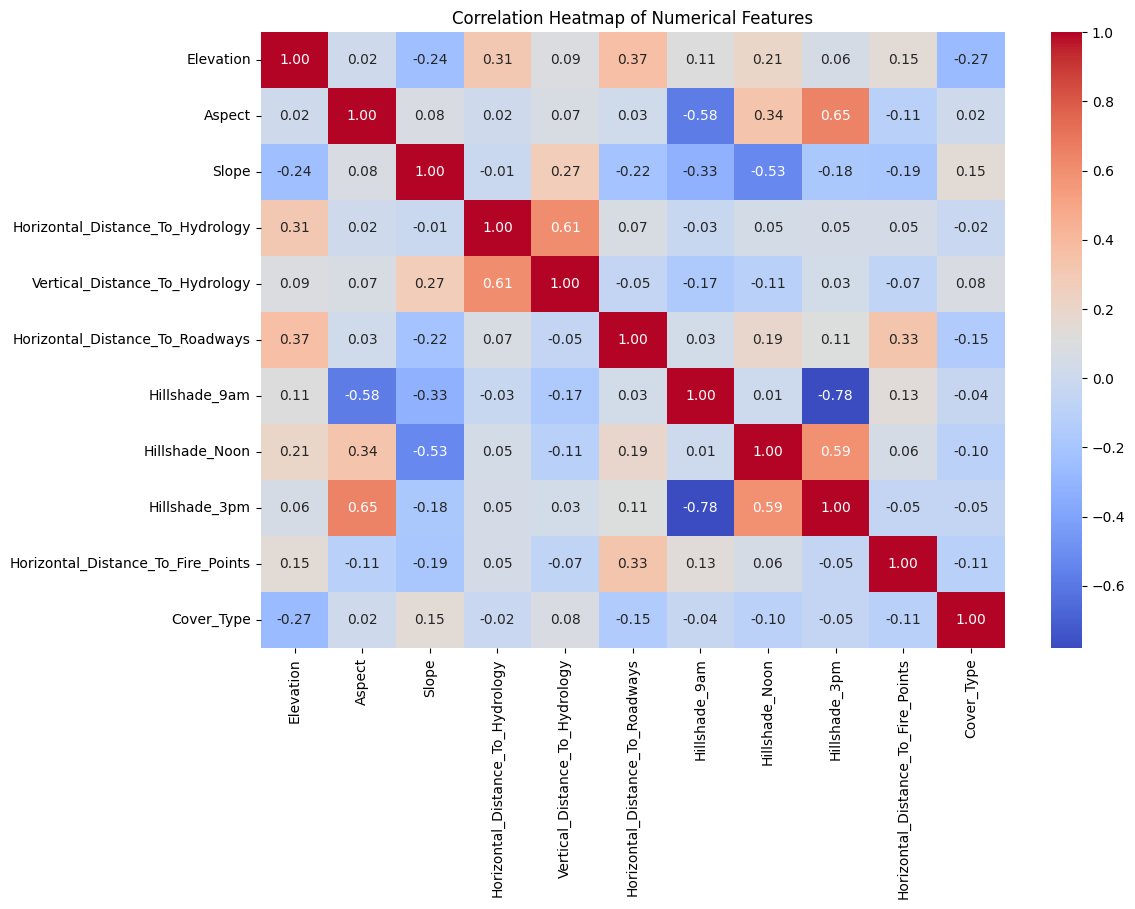

In [28]:
plt.figure(figsize=(12, 8))
correlation_matrix = numerical_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features');

In [29]:
sizeBefore = df.shape[0]

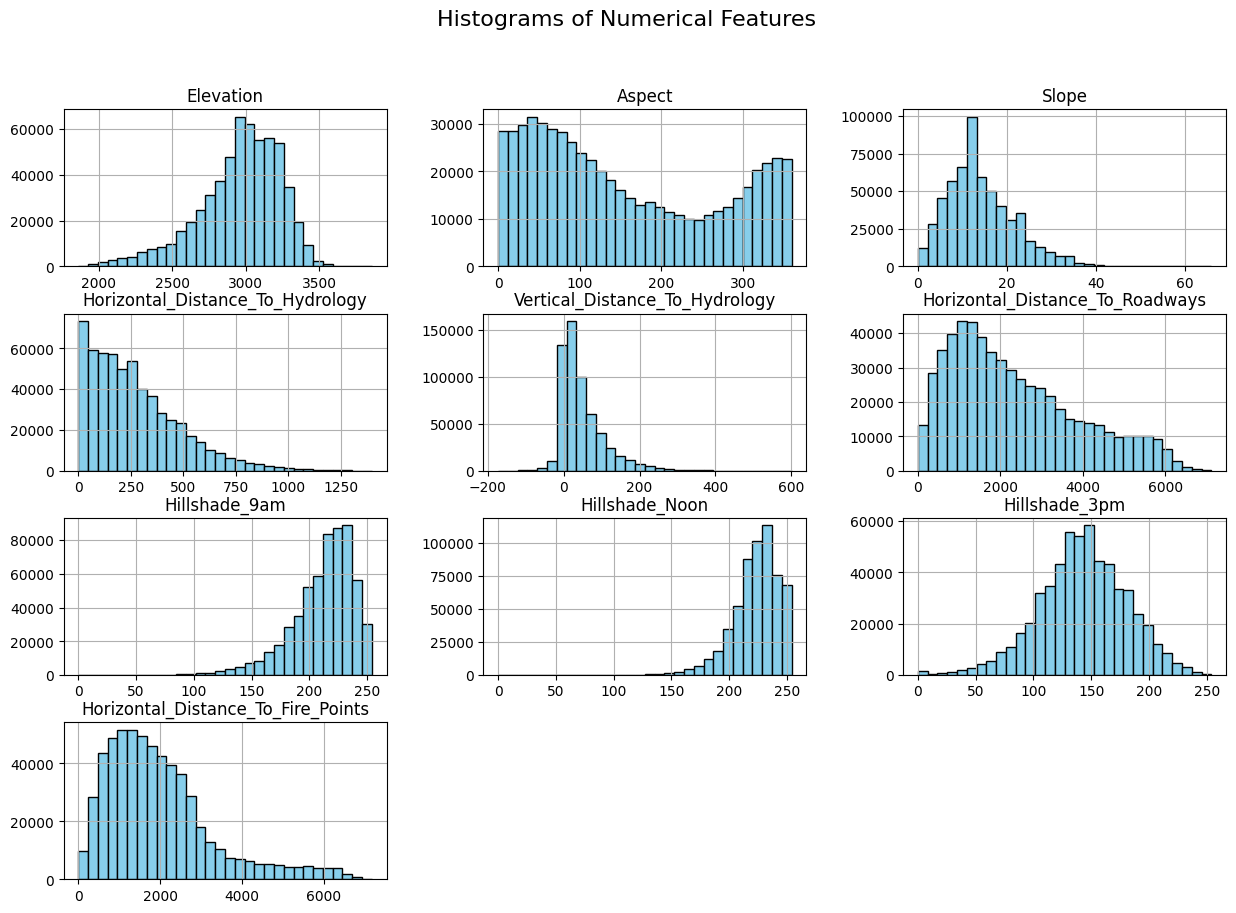

In [30]:
first_10_features.hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle('Histograms of Numerical Features', fontsize=16);

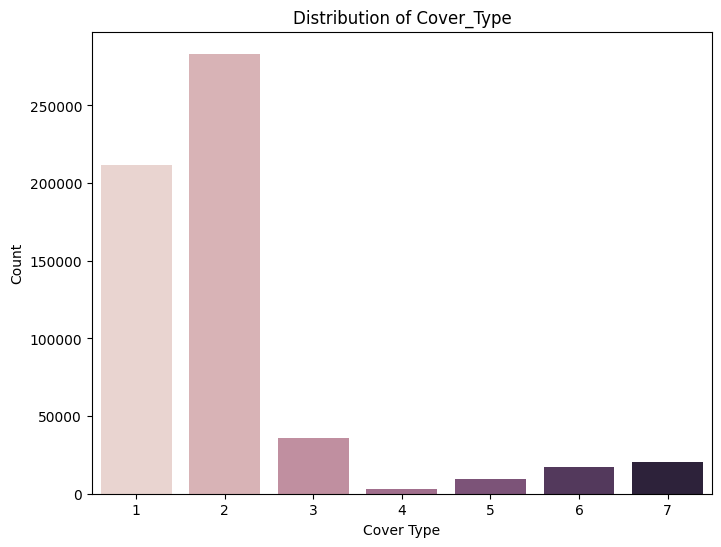

In [31]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Cover_Type', data=df, hue='Cover_Type', dodge=False, legend=False,)
plt.title('Distribution of Cover_Type')
plt.xlabel('Cover Type')
plt.ylabel('Count');

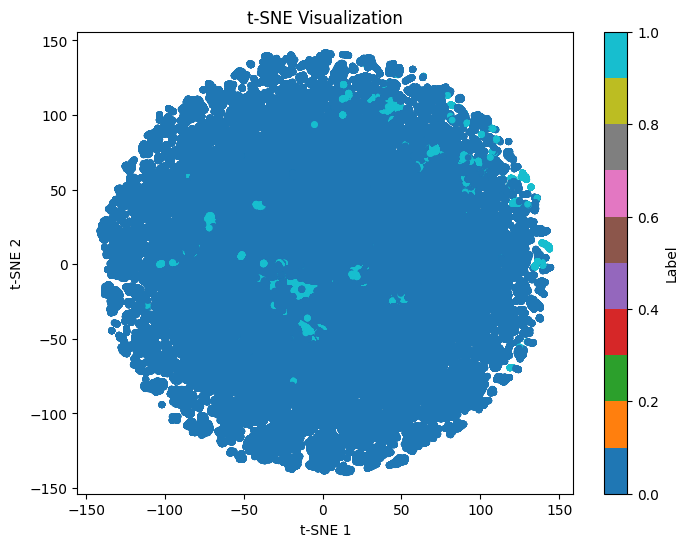

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits  # Example high-dimensional dataset

# Load example data (64-dimensional images of digits)
# Separate features and labels (assumes labels are in the last column)
X = df_prepared[:, :-1]
y = df_prepared[:, -1]

# Run t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X)

# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=15)
plt.colorbar(scatter, label='Label')
plt.title("t-SNE Visualization")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()
# Initialize and run t-SNE
# tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
# tsne_results = tsne.fit_transform(df_prepared)

# # Plot the 2D t-SNE result
# plt.figure(figsize=(8, 6))
# scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels, cmap='tab10', s=15)
# plt.colorbar(scatter, label='Digit Label')
# plt.title("t-SNE Visualization of Digits Dataset")
# plt.xlabel("t-SNE 1")
# plt.ylabel("t-SNE 2")
# plt.show()

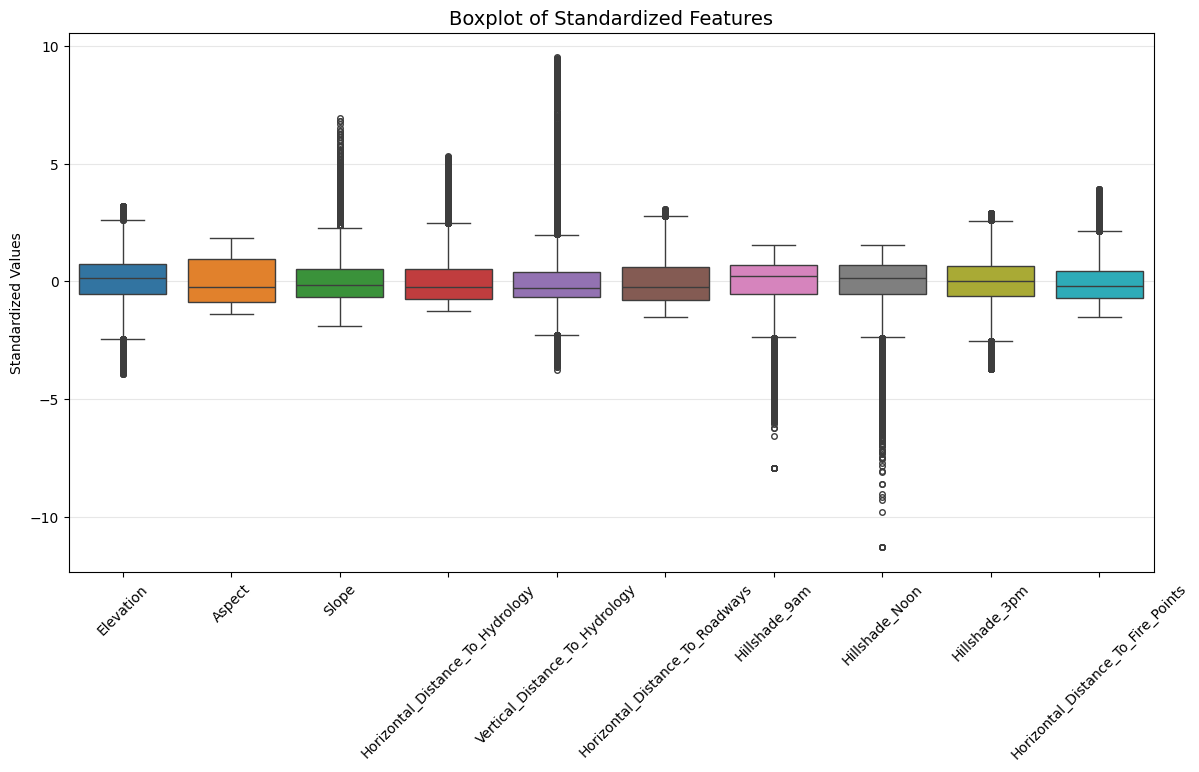

In [33]:

plt.figure(figsize=(14, 7))

# 1. Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(first_10_features)

# 2. Convert back to DataFrame (keeping column names)
scaled_df = pd.DataFrame(scaled_data, columns=first_10_features.columns)

# 3. Plot the scaled data
sns.boxplot(data=scaled_df, showfliers=True, fliersize=4)
plt.title("Boxplot of Standardized Features", fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.ylabel("Standardized Values")
plt.show()

In [3]:
from IPython.display import IFrame
IFrame(src="eyJrIjoiY2E3OTU1MGMtNjgwMy00YjJlLWE5OGQtODQxZjU1NjRlNzk4IiwidCI6ImVhZjYyNGM4LWEwYzQtNDE5NS04N2QyLTQ0M2U1ZDc1MTZjZCIsImMiOjh9", width='1600px', height='900px')


<div style="background-color: #c1e000; border-left: 7px solid #048200; padding: 10px;">
<strong style="color: whight;font-weight: bold;font-size: 25px;">Preprocessing</strong> 
</div>

🔄 Data Preparation & Modeling Pipeline

To build a robust classifier on the Forest CoverType dataset, we followed the steps below:
1. 🧩 Class Consolidation

    The target variable Cover_Type originally contains 7 classes. However, class distribution is highly imbalanced — Classes 1 and 2 dominate the dataset.
    
    To address this, we combined Classes 3 to 7 into a single class called Other, resulting in a 3-class classification problem:
| Original Class | New Class |
| -------------- | --------- |
| 1              | 1         |
| 2              | 2         |
| 3–7            | Other     |


This consolidation helps to:

    .Simplify the classification task

    .Improve model generalization

    .Handle extreme class imbalance more effectively



In [34]:
class1 = int((last_feature==1).sum())
class2 = int((last_feature==2).sum())
others = last_feature.shape[0]-class1-class2

for column in first_10_features.columns:
    data = first_10_features[column]
    
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    
    lower_bound = q1 - 2 * iqr
    upper_bound = q3 + 2 * iqr
    
    outliers_mask = (data < lower_bound) | (data > upper_bound)
    outliers = data[outliers_mask]
    
    outlier_classes = last_feature[outliers_mask]
    first_10_features = first_10_features[~outliers_mask]
    last_feature = last_feature[~outliers_mask]
    numerical_features = numerical_features[~outliers_mask]
    df = df[~outliers_mask]

    class_1_outliers = int((outlier_classes == 1).sum())  # Convert to int
    class_2_outliers = int((outlier_classes == 2).sum())  # Convert to int
    other_outliers = int(len(outliers) - class_1_outliers - class_2_outliers)  # Convert to int
    
    # Calculate percentages (ensure we handle division by zero)
    total_outliers = len(outliers)
    if total_outliers > 0:
        class_1_percent = float((class_1_outliers / total_outliers) * 100)
        class_2_percent = float((class_2_outliers / total_outliers) * 100)
        other_percent = float((other_outliers / total_outliers) * 100)
    else:
        class_1_percent = class_2_percent = other_percent = 0.0
    
    print(f"\nColumn: {column}")
    print(f"Total Outliers: {total_outliers} (out of {len(data)})")
    print("-" * 40)
    print(f"Outliers in Class 1: {class_1_outliers} ({class_1_percent:.1f}%) {(class_1_outliers/class1)*100 :.2f}%" )
    print(f"Outliers in Class 2: {class_2_outliers} ({class_2_percent:.1f}%) {(class_2_outliers/class2)*100 :.2f}%")
    print(f"Outliers in Other Classes: {other_outliers} ({other_percent:.1f}%) {(other_outliers/others)*100 :.2f}%")
    print("-" * 40)

/tmp/ipykernel_432798/1359546720.py:1: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  class1 = int((last_feature==1).sum())
/tmp/ipykernel_432798/1359546720.py:2: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  class2 = int((last_feature==2).sum())
/tmp/ipykernel_432798/1359546720.py:24: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  class_1_outliers = int((outlier_classes == 1).sum())  # Convert to int
/tmp/ipykernel_432798/1359546720.py:25: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  class_2_outliers = int((outlier_classes == 2).sum())  # Convert to int



Column: Elevation
Total Outliers: 4729 (out of 581012)
----------------------------------------
Outliers in Class 1: 0 (0.0%) 0.00%
Outliers in Class 2: 0 (0.0%) 0.00%
Outliers in Other Classes: 4729 (100.0%) 5.51%
----------------------------------------

Column: Aspect
Total Outliers: 0 (out of 576283)
----------------------------------------
Outliers in Class 1: 0 (0.0%) 0.00%
Outliers in Class 2: 0 (0.0%) 0.00%
Outliers in Other Classes: 0 (0.0%) 0.00%
----------------------------------------

Column: Slope
Total Outliers: 3591 (out of 576283)
----------------------------------------
Outliers in Class 1: 796 (22.2%) 0.38%
Outliers in Class 2: 1262 (35.1%) 0.45%
Outliers in Other Classes: 1533 (42.7%) 1.79%
----------------------------------------

Column: Horizontal_Distance_To_Hydrology
Total Outliers: 5171 (out of 572692)
----------------------------------------
Outliers in Class 1: 1298 (25.1%) 0.61%
Outliers in Class 2: 2632 (50.9%) 0.93%
Outliers in Other Classes: 1241 (24.0%

📊 Outlier Detection and Removal using IQR

After reclassifying the target into three groups — Class 1, Class 2, and Other (combining original classes 3–7) — we performed outlier detection and removal manually using the IQR method from scratch with NumPy.
📌 Why Outlier Removal?

Outliers can distort the performance of machine learning models, especially with sensitive algorithms like SVM. However, since the Other class is composed of rare categories, we treat it differently during outlier handling.
🧮 IQR-Based Outlier Detection (from Scratch)

We implemented the Interquartile Range (IQR) method manually:

    1.For each numerical feature, we calculated:

        .Q1: 25th percentile

        .Q3: 75th percentile

        .IQR = Q3 - Q1

    2.We defined the outlier range as:
    Outliers=values <Q1−2.5×IQRorvalues >Q3+2.5×IQR
    Outliers=values <Q1−2.5×IQRorvalues >Q3+2.5×IQR

        Note: We used 2.5 instead of the usual 1.5 to reduce the risk of removing valid values.

🚫 Selective Outlier Removal

We applied this outlier detection process only to samples in Class 1 and Class 2, as these have enough data to tolerate outlier removal.
For the Other class (minority class), we retained all data points, assuming potential "outliers" might actually represent legitimate class characteristics.
✅ Summary:

    .Built IQR logic manually with NumPy

    .Identified outliers based on 2.5×IQR rule

    .Removed outliers only from Class 1 and Class 2

    .Kept all samples from the Other class

In [35]:
sizeAfter = df.shape[0]

In [36]:
deletedRows = sizeBefore - sizeAfter
deletedRows

57650

<div style="background-color: #c1e000; border-left: 7px solid #048200; padding: 10px;">
<strong style="color: whight;font-weight: bold;font-size: 25px;">Model Building</strong> 
</div>

1. 📉 Dimensionality Reduction with LDA

We applied Linear Discriminant Analysis (LDA) for dimensionality reduction.

    .LDA is a supervised technique that maximizes class separability.

    .It reduces the feature space while preserving the information most relevant for classification.

    .Since our target is known and categorical, LDA is ideal here.

2. 📏 Feature Scaling

Before applying LDA and SMOTE, we scaled the features using StandardScaler:

    .Ensures features are on the same scale

    .Prevents bias toward variables with larger ranges

    .Essential for LDA and SVM to perform optimally

3. ⚖️ Handling Imbalanced Data with SMOTE

Even after merging classes, class imbalance remained.
To address this, we used SMOTE (Synthetic Minority Over-sampling Technique):

    .Generates synthetic examples for minority classes

    .Helps the model avoid bias toward the majority class

    .Improves generalization to underrepresented groups

4. 🔍 Hyperparameter Tuning with SVM & RandomizedSearchCV

We used a Support Vector Machine (SVM) classifier due to its effectiveness in high-dimensional spaces.

To optimize performance, we performed hyperparameter tuning using RandomizedSearchCV, which:

    .Efficiently searches the hyperparameter space

    .Randomly samples combinations of parameters

    .Evaluates using cross-validation to avoid overfitting

🧠 Final Pipeline Summary

    1.Combine target classes (3–7 → Other)

    2.Standardize features

    3.Apply LDA to reduce dimensions

    4.Balance the dataset using SMOTE

    5.Train and tune SVM using RandomizedSearchCV



In [37]:


categorical_features = df.iloc[:, 10:-1].columns  # Wilderness_Area and Soil_Type columns

# Numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('std_scaler', StandardScaler()),  
    
])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, first_10_features.columns), 
    # ("cat", OneHotEncoder(), categorical_features),  #if i want to use OneHotEncoder
    ("cat", "passthrough", categorical_features),
    ('lda',LinearDiscriminantAnalysis(n_components=2),df.columns)
])



In [38]:
def split_train_test(data, test_ratio ,SEED=42):
    np.random.seed(SEED)
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [39]:
train,test = split_train_test(df,0.2)

In [40]:
train_prepared = full_pipeline.fit_transform(train)

In [41]:
train_prepared.shape

(418690, 54)

In [42]:
test_prepared = full_pipeline.transform(test)

In [69]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import time
from tqdm import tqdm
import psutil
from sklearn.model_selection import RandomizedSearchCV
print(f"Memory usage: {psutil.Process().memory_info().rss / 1024 ** 2:.2f} MB")


Memory usage: 2042.82 MB


In [70]:
def map_classes(x):
    if x == 1:
        return 1  # Class A
    elif x == 2:
        return 2  # Class B
    else:
        return 3  # Others

In [71]:
def tune_svm(X_train, y_train):
    """Perform hyperparameter tuning with progress tracking"""
    print("Starting SVM tuning...")
    
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        'kernel': ['rbf', 'poly', 'sigmoid'],
        'class_weight': ['balanced', None]
    }

    # param_grid = {
    # 'C': [ 10],  # Reduced from 4
    # 'gamma': ['scale'],  # Reduced from 5
    # 'kernel': ['rbf'],  # Single kernel
    # 'class_weight': ['balanced']  # Single option
    # }
    # Use 10% data for initial parameter search
    svm = SVC(probability=True, random_state=42)
    
    # Wrap GridSearchCV with tqdm for progress tracking
    
    with tqdm(total=len(param_grid['C']) * len(param_grid['gamma']) * 
                len(param_grid['kernel']) * len(param_grid['class_weight']) * 5) as pbar:
        
        def update_pbar(*args, **kwargs):
            pbar.update(1)
            
        grid_search = RandomizedSearchCV(
            svm, param_grid, cv=5, scoring='accuracy', 
            n_jobs=-1, verbose=1, pre_dispatch='2*n_jobs',
            error_score='raise')
        
        grid_search.fit(X_train, y_train)
        pbar.close()
    
    return grid_search

In [72]:
def evaluate_model(model, X_test, y_test):
    """Evaluate model"""
    print("\nEvaluating model...")
    y_pred = model.predict(X_test)
    
    print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    

<div style="background-color: #c1e000; border-left: 7px solid #048200; padding: 10px;">
<strong style="color: whight;font-weight: bold;font-size: 25px;">Saving The model</strong> 
</div>

In [ ]:
# Main execution flow
if __name__ == "__main__":
    try:
        #1.Class Grouping
        df['Cover_Type'] = df['Cover_Type'].apply(map_classes)

        
        # 2. Seperate data
        X = df.iloc[:,:-1] #<----- data here
        y = df['Cover_Type']         #<------target column
        
        # 3. split data to train and test
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
        print("Split data...")
        print(f"Training shape: {X_train.shape}")
        print(f"Test shape: {X_test.shape}")

        
        # 4.scale features 
        scaler =StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)    
        print("Scale data...")
        
        # 5.apply LDA 
        lda = LinearDiscriminantAnalysis(n_components=2)
        X_train_lda = lda.fit_transform(X_train_scaled, y_train)
        X_test_lda = lda.transform(X_test_scaled)
        print("Apply LDA...")
        print(f"Training shape: {X_train_lda.shape}")
        print(f"Test shape: {X_test_lda.shape}")
        
        
                
        # #take small sample to test it 
        # X_train_sm, y_train_sm = resample(X_train_lda, y_train,n_samples=10000, random_state=42)
        # print(f"Training shape: {X_train_sm.shape}")
        # print(f"Test shape: {X_test_lda.shape}")

        
        # 6.Handle class imbalance
        print("Handling class imbalance...")
        smote = SMOTE(random_state=42)
        X_train_res,y_train_res=smote.fit_resample(X_train_lda, y_train)
        
        # 7. Tune SVM (with timing)
        start_time = time.time()
        grid_search = tune_svm(X_train_res, y_train_res)
        print(f"\nTuning completed in {time.time()-start_time:.2f} seconds")
                
        # 7. Evaluate best model
        best_svm = grid_search.best_estimator_
        print(f"\nBest Parameters: {grid_search.best_params_}")
        print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")
        
        evaluate_model(best_svm, X_test_lda, y_test)
                
    except Exception as e:
        print(f"\nError encountered: {str(e)}")
        raise

In [80]:
import joblib as jl

moddl = grid_search.best_estimator_
jl.dump(moddl,'model.pkl')

['model.pkl']